In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Reading an image as gray scale image.

img = cv2.imread('lab7/car.jpg',0)

In [3]:
#Defining your own kernel: first derivative filter
#kernal sensitive to horizontal lines
kernel = np.array([[-1.0, -1.0], 
                   [2.0, 2.0],
                   [-1.0, -1.0]])
kernel = kernel/(np.sum(kernel) if np.sum(kernel)!=0 else 1)
kernel

array([[-1., -1.],
       [ 2.,  2.],
       [-1., -1.]])

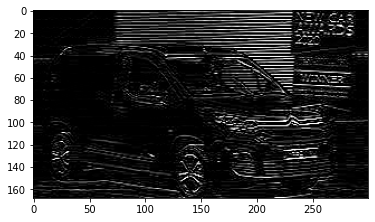

In [4]:
#filter the source image
img_rst = cv2.filter2D(img,-1,kernel)

#save and show the result image
#cv2.imwrite('result.jpg',img_rst)
plt.imshow(img_rst,'gray')

# First Derivertive Edge Filters

#### Sebel edge detector

In [5]:
img = cv2.imread('lab7/car.jpg',0)

#Sobel Edge detector
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)

sobelx[50:60, 50:60]

array([[ 8., 10., 10.,  8.,  5.,  5.,  4.,  4.,  8.,  8.],
       [ 8.,  9., 10.,  9.,  4.,  3.,  3.,  4.,  8.,  8.],
       [ 8.,  8., 10., 10.,  4.,  1.,  1.,  4.,  8.,  8.],
       [ 8.,  8.,  9.,  9.,  5.,  0., -1.,  4.,  8.,  8.],
       [ 8.,  8.,  9.,  8.,  6.,  0., -3.,  4.,  8.,  8.],
       [ 7.,  8., 10.,  7.,  5.,  3.,  0.,  4.,  7.,  8.],
       [ 5.,  8.,  9.,  5.,  4.,  9.,  8.,  4.,  5.,  8.],
       [ 4.,  8.,  8.,  4.,  4., 12., 12.,  4.,  4.,  8.],
       [ 4.,  8.,  8.,  4.,  4., 12., 12.,  4.,  4.,  8.],
       [ 4.,  8.,  8.,  4.,  4., 12., 12.,  4.,  4.,  8.]])

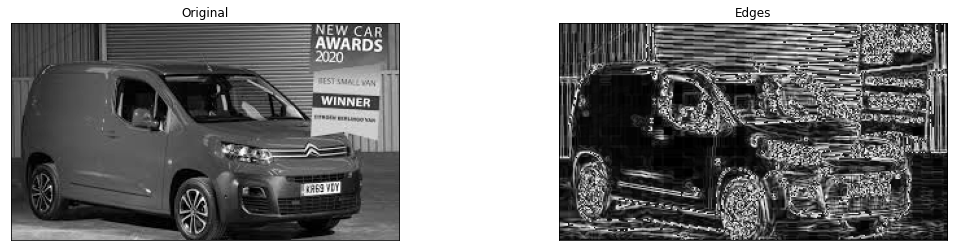

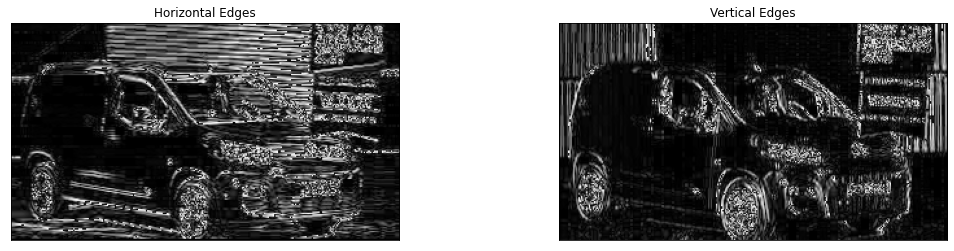

In [6]:
#convert to 8 bits, we use 64 bits to handle negative value caused from white-to-black edge which has negative gradient
abs_sobel64f = np.absolute(sobelx)
sobelx = np.uint8(abs_sobel64f)
abs_sobel64f = np.absolute(sobely)
sobely = np.uint8(abs_sobel64f)

sobel = np.uint8(sobelx+sobely)

plt.figure(figsize=(18,4))
plt.subplot(121),plt.imshow(img,'gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sobel,'gray'),plt.title('Edges')
plt.xticks([]), plt.yticks([])

plt.figure(figsize=(18,4))
plt.subplot(121),plt.imshow(sobely,'gray'),plt.title('Horizontal Edges')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sobelx,'gray'),plt.title('Vertical Edges')
plt.xticks([]), plt.yticks([])
plt.show()


# Second Derivertive Edge Filter

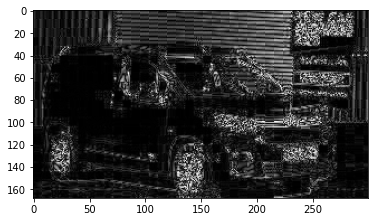

In [7]:
laplacian = cv2.Laplacian(img,cv2.CV_64F)
abs_sobel64f = np.absolute(laplacian)
laplacian = np.uint8(abs_sobel64f)

plt.imshow(laplacian, 'gray')

# Canny Edges

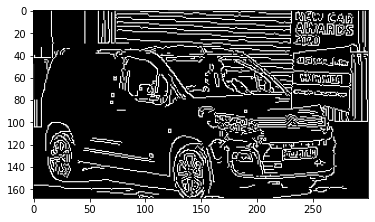

In [8]:
#Canny Edge Filters (First derivative with maximum supression and hysteresis thresholding)
#Explanation, pls see http://fourier.eng.hmc.edu/e161/lectures/canny/node1.html

canny = cv2.Canny(img,80,200)
plt.imshow(canny, 'gray')

In [9]:
#Several libraries provides functions to perform filterings. 
#https://scikit-image.org/docs/dev/api/skimage.filters.html?highlight=convolution

# One Important Matter!
In our last example, output datatype is cv.CV_8U or np.uint8. 
But edges can be positive edge (gray value change from Black-to-White) while the transition from White-to-Black is taken as a Negative slope (negative edge). 
So after data coversion to np.uint8, all negative edges are mapped to zero. 

To maintain both types of edges, the output datatype is mapped to some higher forms, like cv.CV_16S, cv.CV_64F etc, take its absolute value and then convert back to cv.CV_8U. 


ref: https://docs.opencv.org/master/d5/d0f/tutorial_py_gradients.html

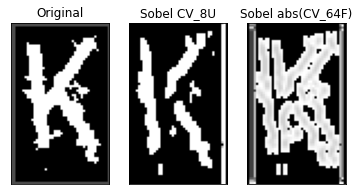

In [10]:
import numpy as np
import cv2 as cv2
from matplotlib import pyplot as plt
img = cv2.imread('lab7/k.png',0)

# Output dtype = cv.CV_8U
sobelx8u = cv2.Sobel(img,cv2.CV_8U,1,0,ksize=5)
# Output dtype = cv2.CV_64F. Then take its absolute and convert to cv.CV_8U
sobelx64f = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)
abs_sobel64f = np.absolute(sobelx64f)
sobel_8u = np.uint8(abs_sobel64f)
plt.subplot(1,3,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(sobelx8u,cmap = 'gray')
plt.title('Sobel CV_8U'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(sobel_8u,cmap = 'gray')
plt.title('Sobel abs(CV_64F)'), plt.xticks([]), plt.yticks([])
plt.show()

### Canny edge detection

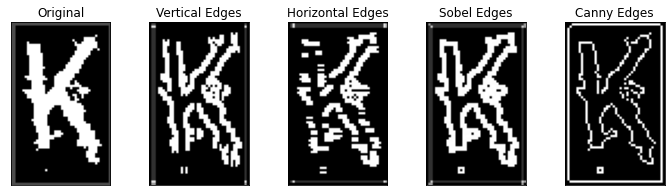

In [11]:
# read image as grayscale
img = cv2.imread('lab7/k.png', cv2.IMREAD_GRAYSCALE)
#Sobel Edge detector
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)

#convert to 8 bits, we use 64 bits to handle negative value caused from white-to-black edge which has negative gradient
abs_sobel64f = np.absolute(sobelx)
sobelx = np.uint8(abs_sobel64f)
abs_sobel64f = np.absolute(sobely)
sobely = np.uint8(abs_sobel64f)

canny = cv2.Canny(img, 100, 200)

plt.figure(figsize=(12,3))
plt.subplot(151),plt.imshow(img,'gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(152),plt.imshow(sobelx,'gray'),plt.title('Vertical Edges')
plt.xticks([]), plt.yticks([])
plt.subplot(153),plt.imshow(sobely,'gray'),plt.title('Horizontal Edges')
plt.xticks([]), plt.yticks([])
plt.subplot(154),plt.imshow(sobelx+sobely,'gray'),plt.title('Sobel Edges')
plt.xticks([]), plt.yticks([])
plt.subplot(155),plt.imshow(canny,'gray'),plt.title('Canny Edges')
plt.xticks([]), plt.yticks([])
plt.show()

(<AxesSubplot:title={'center':'Canny Edges'}>,
 Text(0.5, 1.0, 'Canny Edges'))

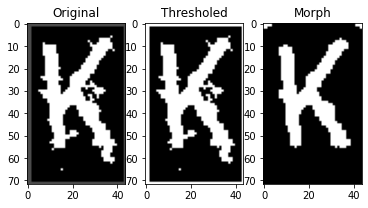

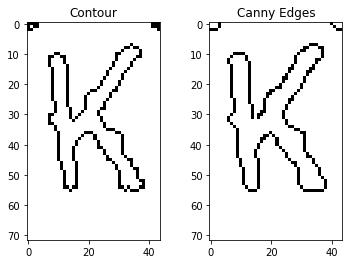

In [12]:
# threshold to binary
thresh = cv2.threshold(img, 0, 128, cv2.THRESH_BINARY)[1]

# apply morphology
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.subplot(1,3,1),plt.imshow(img,cmap = 'gray'), plt.title('Original')
plt.subplot(1,3,2),plt.imshow(thresh, cmap= 'gray'), plt.title('Thresholed')
plt.subplot(1,3,3),plt.imshow(morph, cmap= 'gray'), plt.title('Morph')

#find contours
imt, contours, hierarchy = cv2.findContours(morph, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#create an empty image for contours
img_contours = np.ones(img.shape)
# draw the contours on the empty image
cv2.drawContours(img_contours, contours, -1, (0,0,0), 1)
plt.figure()
plt.subplot(1,2,1),plt.imshow(img_contours, cmap= 'gray'), plt.title('Contour')
# do canny edge detection
edges = cv2.Canny(morph, 200, 200)
plt.subplot(1,2,2),plt.imshow(np.invert(edges), cmap= 'gray'), plt.title('Canny Edges')

# Hough Line

lines = cv2.HoughLines(image,rho,theta,threshold) 

<br>image : Input image should be a binary image, so apply threshold or use canny edge detection before finding applying hough transform. 
<br>\rho and \theta accuracies respectively.
<br>threshold: minimum vote it should get for it to be considered as a line. 
<br>Remember, number of votes depend upon number of points on the line. 
<br>So it represents the minimum length of line that should be detected.

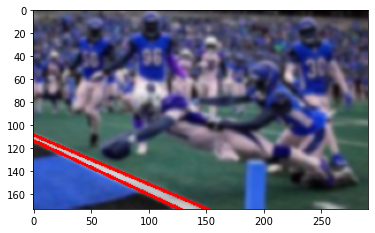

In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('../images/p07/touchdown 1.jpg')
img = cv2.GaussianBlur(img,(9,9),0)
gimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gimg,150,200)

plt.imshow(edges)

# Copy edges to the images that will display the results in BGR
dimp = np.copy(img)
    
lines = cv2.HoughLines(edges,1,np.pi/180,80)

#lines = cv2.HoughLines(edges, np.pi/180, 150, None, 0, 0)
#lines = cv2.HoughLinesP(E,rho = 1,theta = 1*np.pi/180,threshold = 100,minLineLength = 100,maxLineGap = 50)

for line in lines:
    rho,theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    cv2.line(img,(x1,y1),(x2,y2),(255,0,0),2)

cv2.imwrite('houghlines3.jpg',img)
plt.imshow(img)

# Houg Circle

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp, min_dist, param1, param2, min_radius, max_radius)

<br>gray: Input image (grayscale).
<br>circles: A vector that stores sets of 3 values: xc,yc,r for each detected circle.
<br>HOUGH_GRADIENT: Define the detection method. Currently this is the only one available in OpenCV.
<br>dp = 1: The inverse ratio of resolution.
<br>min_dist = gray.rows/16: Minimum distance between detected centers.
<br>param_1 = 200: Upper threshold for the internal Canny edge detector.
<br>param_2 = 100*: Threshold for center detection.
<br>min_radius = 0: Minimum radius to be detected. If unknown, put zero as default.
<br>max_radius = 0: Maximum radius to be detected. If unknown, put zero as default.